# AWG Brands Pricing & Sales Data Quality Report

---

## University of Illinois - Spring 2026 Project

**Prepared for:** Tyler Olinger & Kate Favrow (AWG)  
**Academic Leads:** Prof. Ashish Khandelwal & Jeremy Samuel  
**Date:** January 2026

---

### Purpose of This Report

This notebook provides a comprehensive audit of the AWG Brands pricing and sales data. The analysis covers:

| Section | Description |
|---------|-------------|
| **Data Structure** | Validation of file formats, columns, and sheets |
| **Completeness** | Missing data analysis across divisions, brands, and categories |
| **Brand Linkage** | Verification of Best Choice to National Brand mappings |
| **Data Quality** | Reasonableness checks, outliers, and consistency |
| **Recommendations** | Actionable insights for data preparation |

---

### How to Use This Notebook

1. **Run All Cells**: Execute cells sequentially from top to bottom
2. **Review Outputs**: Each section includes tables, charts, and interpretations
3. **Check Issues Table**: Section 9 consolidates all identified issues
4. **Follow Recommendations**: Section 10 provides next steps

> **Note:** This notebook is designed as a teaching aid. Each section includes explanations of the methodology and interpretation of results.

---

# 1. Executive Summary

---

## Overview

This section provides a high-level summary of data quality findings. **After running all cells**, update this summary with actual results.

### Data Completeness Status

| Dataset | Status | Notes |
|---------|--------|-------|
| Pricing File | To be assessed | Expected: ~4,300 products × 229 columns |
| Sales File | To be assessed | Expected: 9 division sheets |

### Key Issues Requiring Attention

- [ ] **Issue 1:** Missing pricing data (~23% expected in KC division)
- [ ] **Issue 2:** Sales sheet naming typos (GO → Nashville, NO → Nebraska)
- [ ] **Issue 3:** Trailing whitespace in "National Brand" label
- [ ] **Issue 4:** Duplicate column names (SRP UNIT QUANTITY)

### Recommendations Summary

1. Clean brand labels before analysis
2. Create sheet name mapping for sales data
3. Document items with missing pricing for AWG clarification
4. Verify National Brand linkage completeness

> **Action Required:** Update this summary after completing the full analysis.

---

# 2. Setup & Data Loading

---

## 2.1 Import Required Libraries

We begin by importing the Python libraries needed for data analysis and visualization.

| Library | Purpose |
|---------|--------|
| `pandas` | Data manipulation and analysis |
| `numpy` | Numerical operations |
| `matplotlib` | Basic plotting |
| `seaborn` | Statistical visualizations |
| `warnings` | Suppress unnecessary warnings |

In [13]:
# =============================================================================
# LIBRARY IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Confirm imports
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.3.1
NumPy version: 2.3.2


## 2.2 Configure Display Settings

These settings ensure that DataFrames display properly in the notebook.

In [14]:
# =============================================================================
# DISPLAY CONFIGURATION
# =============================================================================

# Pandas display options
pd.set_option('display.max_columns', 50)      # Show up to 50 columns
pd.set_option('display.max_rows', 100)        # Show up to 100 rows
pd.set_option('display.width', None)          # Auto-detect display width
pd.set_option('display.max_colwidth', 50)     # Truncate long column content
pd.set_option('display.float_format', '{:,.2f}'.format)  # Format floats

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')       # Clean, professional style
plt.rcParams['figure.figsize'] = [12, 6]     # Default figure size
plt.rcParams['font.size'] = 10               # Default font size

# Seaborn configuration
sns.set_palette('husl')                       # Colorful palette

print("Display settings configured!")

Display settings configured!


## 2.3 Define File Paths

Update these paths to match your local environment.

### File Locations

| File | Description | Header Row |
|------|-------------|------------|
| Pricing File | Product details with quarterly pricing by division | Row 3 (0-indexed) |
| Sales File | Sales data with 9 division sheets | Row 2 (0-indexed) |

In [15]:
# =============================================================================
# FILE PATH CONFIGURATION
# =============================================================================

# Define file paths
PRICING_FILE = r'C:\Users\ashishk\Dropbox\My PC (BUS-P10E67720)\Documents\Development\AWG_Spring_26\Product Details & Pricing by quarter by division 12.19.25.xlsx'
SALES_FILE = r'C:\Users\ashishk\Dropbox\My PC (BUS-P10E67720)\Documents\Development\AWG_Spring_26\Sales Data by Quarter - U of I Project 12.19.25.xlsx'

print(f"Pricing file: {PRICING_FILE}")
print(f"Sales file: {SALES_FILE}")

Pricing file: C:\Users\ashishk\Dropbox\My PC (BUS-P10E67720)\Documents\Development\AWG_Spring_26\Product Details & Pricing by quarter by division 12.19.25.xlsx
Sales file: C:\Users\ashishk\Dropbox\My PC (BUS-P10E67720)\Documents\Development\AWG_Spring_26\Sales Data by Quarter - U of I Project 12.19.25.xlsx


## 2.4 Define Constants and Mappings

These constants define the expected data structure and help with data validation.

### Division Information

| Code | Division Name | Region |
|------|--------------|--------|
| KC | Kansas City | Central |
| SP | Springfield | Central |
| OK | Oklahoma | South |
| NA | Nashville | Southeast |
| GC | Gulf Coast | South |
| NE | Nebraska | North |
| GL | Great Lakes | North |
| HN | Hernando | Southeast |
| UM | Upper Midwest | North |

### Quarter Mapping

| Suffix | Quarter | Period |
|--------|---------|--------|
| (none) | Q1 | Nov 2024 - Jan 2025 |
| .1 | Q2 | Feb 2025 - Apr 2025 |
| .2 | Q3 | May 2025 - Jul 2025 |
| .3 | Q4 | Aug 2025 - Oct 2025 |

In [16]:
# =============================================================================
# CONSTANTS AND MAPPINGS
# =============================================================================

# Division codes and full names
DIVISIONS = {
    'KC': 'Kansas City',
    'SP': 'Springfield',
    'OK': 'Oklahoma',
    'NA': 'Nashville',
    'GC': 'Gulf Coast',
    'NE': 'Nebraska',
    'GL': 'Great Lakes',
    'HN': 'Hernando',
    'UM': 'Upper Midwest'
}

# Sales sheet name corrections (known typos)
SHEET_NAME_CORRECTIONS = {
    'GO Division Sales': 'NA',  # GO is actually Nashville
    'NO Division Sales': 'NE'   # NO is actually Nebraska
}

# Quarter suffixes in column names
QUARTER_SUFFIXES = {
    '': 'Q1',      # No suffix = Q1
    '.1': 'Q2',    # .1 suffix = Q2
    '.2': 'Q3',    # .2 suffix = Q3
    '.3': 'Q4'     # .3 suffix = Q4
}

# Price field types
PRICE_FIELDS = [
    'LIST COST',
    'BSP',
    'SRP UNIT QUANTITY',
    'CITY SRP',
    'RURAL SRP'
]

# Product attribute columns (first 13 columns)
PRODUCT_COLUMNS = [
    'Item Code',
    'Item Unit UPC Code',
    'Case UPC Code',
    'Size',
    'Pack (Units per Case)',
    'Item Name',
    'Inventory Department',
    'Category',
    'Sub Category',
    'Brand Label Name',
    'Brand Name',
    'Item Long Description',
    'National Comparison Item Code'
]

# Expected brand labels
EXPECTED_BRANDS = ['Best Choice', 'Always Save', 'National Brand']

print("Constants defined successfully!")
print(f"\nDivisions: {list(DIVISIONS.keys())}")
print(f"Quarters: {list(QUARTER_SUFFIXES.values())}")
print(f"Price fields: {PRICE_FIELDS}")

Constants defined successfully!

Divisions: ['KC', 'SP', 'OK', 'NA', 'GC', 'NE', 'GL', 'HN', 'UM']
Quarters: ['Q1', 'Q2', 'Q3', 'Q4']
Price fields: ['LIST COST', 'BSP', 'SRP UNIT QUANTITY', 'CITY SRP', 'RURAL SRP']


## 2.5 Load Pricing Data

The pricing file contains product details and quarterly pricing information across all divisions.

### Key Points:
- **Header row**: Row 3 (0-indexed), so we use `header=3`
- **Expected columns**: 13 product columns + 216 pricing columns = 229 total
- **Pricing columns**: 9 divisions × 4 quarters × 6 price fields = 216

In [17]:
# =============================================================================
# LOAD PRICING DATA
# =============================================================================

def load_pricing_data(filepath):
    """
    Load the pricing Excel file with correct header row.
    
    Parameters:
    -----------
    filepath : str
        Path to the pricing Excel file
        
    Returns:
    --------
    pd.DataFrame
        Pricing data with cleaned column names
    """
    try:
        # Read Excel with header at row 3 (0-indexed)
        df = pd.read_excel(filepath, header=3)
        
        # Clean column names (strip whitespace)
        df.columns = df.columns.str.strip()
        
        print(f"Successfully loaded pricing data!")
        print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
        
        return df
    
    except FileNotFoundError:
        print(f"ERROR: File not found at {filepath}")
        print("Please update the PRICING_FILE path.")
        return None
    
    except Exception as e:
        print(f"ERROR loading file: {e}")
        return None

# Load the data
df_pricing = load_pricing_data(PRICING_FILE)

# Verify column count
if df_pricing is not None:
    expected_cols = 229  # 13 product + 216 pricing
    actual_cols = len(df_pricing.columns)
    
    if actual_cols == expected_cols:
        print(f"\n✓ Column count matches expected: {actual_cols}")
    else:
        print(f"\n⚠ Column count mismatch!")
        print(f"  Expected: {expected_cols}")
        print(f"  Actual: {actual_cols}")

Successfully loaded pricing data!
Shape: 4,319 rows × 229 columns

✓ Column count matches expected: 229


In [18]:
df_pricing.head()

,Item Code,Item Unit UPC Code,Case UPC Code,Size,Pack (Units per Case),Item Name,Inventory Department,Category,Sub Category,Brand Label Name,Brand Name,Item Long Description,National Comparison Item Code,KC LIST COST,KC BSP,KC SRP UNIT QUANTITY,KC CITY SRP,KC SRP UNIT QUANTITY.1,KC RURAL SRP,KC LIST COST.1,KC BSP.1,KC SRP UNIT QUANTITY.2,KC CITY SRP.1,KC SRP UNIT QUANTITY.3,KC RURAL SRP.1,...,HN RURAL SRP.3,UM LIST COST,UM BSP,UM SRP UNIT QUANTITY,UM CITY SRP,UM SRP UNIT QUANTITY.1,UM RURAL SRP,UM LIST COST.1,UM BSP.1,UM SRP UNIT QUANTITY.2,UM CITY SRP.1,UM SRP UNIT QUANTITY.3,UM RURAL SRP.1,UM LIST COST.2,UM BSP.2,UM SRP UNIT QUANTITY.4,UM CITY SRP.2,UM SRP UNIT QUANTITY.5,UM RURAL SRP.2,UM LIST COST.3,UM BSP.3,UM SRP UNIT QUANTITY.6,UM CITY SRP.3,UM SRP UNIT QUANTITY.7,UM RURAL SRP.3
0,31120,7003866694,7003866694,50 CT,1,AL SAVE CHST&NASL PE,Health Beauty Care,COUGH & COLD REMEDIES,COLD REMEDIES - ADULT,Always Save,ALWAYS SAVE,CHEST & NASAL CONGESTION PE RELIEF CAPLETS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31139,7003866837,7003866837,500 CT,1,AL SAVE PN RLF CAPS,Health Beauty Care,PAIN REMEDIES,PAIN RELIEVERS - NON ASPIRIN,Always Save,ALWAYS SAVE,ACETAMINOPHEN PAIN RELIEF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,37447,7003866701,7003866701,1 OZ,1,AL SAVE BACITRCN OIT,Health Beauty Care,FIRST AID,GERMICIDAL ANTISEPTICS,Always Save,ALWAYS SAVE,BACITRACIN OINTMENT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,37573,7003866699,7003866699,1 OZ,1,AL SAVE 1% HYDO CRM,Health Beauty Care,FIRST AID,ANTI-ITCH CREAMS & LOTIONS,Always Save,ALWAYS SAVE,1% HYDROCORTISONE CREAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45491,7003867293,7003867293,15 LB,1,AL SAVE CHUNK DOG FD,Grocery - Dry,PET CARE,DOG FOOD-DRY VALUE,Always Save,ALWAYS SAVE,CHUNK DOG FOOD,NaN,9.98,11.00,1.00,13.69,1.00,13.69,9.98,11.00,1.00,13.69,1.00,13.69,...,12.69,9.54,11.00,1.00,13.69,1.00,13.69,9.54,11.00,1.00,13.69,1.00,13.69,9.54,10.19,1.00,12.69,1.00,12.69,9.54,10.19,1.00,12.69,1.00,12.69


## 2.6 Load Sales Data

The sales file contains 9 sheets, one for each division. Each sheet has quarterly sales data.

### Key Points:
- **Header row**: Row 2 (0-indexed), so we use `header=2`
- **Known typos**: "GO Division Sales" → Nashville, "NO Division Sales" → Nebraska
- **Sales columns**: $ SALES and BILLED CASE QUANTITY for each quarter

In [19]:
# =============================================================================
# LOAD SALES DATA
# =============================================================================

def load_sales_data(filepath):
    """
    Load all sheets from the sales Excel file.
    
    Parameters:
    -----------
    filepath : str
        Path to the sales Excel file
        
    Returns:
    --------
    dict
        Dictionary with sheet names as keys and DataFrames as values
    """
    try:
        # Get all sheet names
        xlsx = pd.ExcelFile(filepath)
        sheet_names = xlsx.sheet_names
        
        print(f"Found {len(sheet_names)} sheets in sales file:")
        for i, name in enumerate(sheet_names, 1):
            print(f"  {i}. {name}")
        
        # Load each sheet
        sales_data = {}
        for sheet in sheet_names:
            df = pd.read_excel(filepath, sheet_name=sheet, header=2)
            df.columns = df.columns.str.strip()
            sales_data[sheet] = df
            
        print(f"\nSuccessfully loaded all sheets!")
        return sales_data
    
    except FileNotFoundError:
        print(f"ERROR: File not found at {filepath}")
        print("Please update the SALES_FILE path.")
        return None
    
    except Exception as e:
        print(f"ERROR loading file: {e}")
        return None

# Load the data
sales_data = load_sales_data(SALES_FILE)

# Display row counts per sheet
if sales_data is not None:
    print("\nRows per sheet:")
    for sheet, df in sales_data.items():
        print(f"  {sheet}: {len(df):,} rows, {len(df.columns)} columns")

Found 9 sheets in sales file:
  1. KC Division Sales
  2. SP Division Sales
  3. OK Division Sales
  4. GO Division Sales
  5. GC Division Sales
  6. NO Division Sales
  7. GL Division Sales
  8. HN Division Sales
  9. UM Division Sales

Successfully loaded all sheets!

Rows per sheet:
  KC Division Sales: 4,353 rows, 19 columns
  SP Division Sales: 4,353 rows, 19 columns
  OK Division Sales: 4,353 rows, 19 columns
  GO Division Sales: 4,353 rows, 19 columns
  GC Division Sales: 4,353 rows, 19 columns
  NO Division Sales: 4,353 rows, 19 columns
  GL Division Sales: 4,353 rows, 19 columns
  HN Division Sales: 4,353 rows, 19 columns
  UM Division Sales: 4,353 rows, 19 columns


## 2.7 Clean Brand Labels

**Known Issue:** The "National Brand" label has trailing whitespace that must be removed for accurate grouping.

In [20]:
# =============================================================================
# CLEAN BRAND LABELS
# =============================================================================

if df_pricing is not None:
    # Check for Brand Label Name column
    if 'Brand Label Name' in df_pricing.columns:
        # Show unique values BEFORE cleaning
        print("Brand labels BEFORE cleaning:")
        print(df_pricing['Brand Label Name'].unique())
        print()
        
        # Strip whitespace from brand labels
        df_pricing['Brand Label Name'] = df_pricing['Brand Label Name'].str.strip()
        
        # Show unique values AFTER cleaning
        print("Brand labels AFTER cleaning:")
        print(df_pricing['Brand Label Name'].unique())
        print()
        
        # Count by brand
        print("Count by brand:")
        print(df_pricing['Brand Label Name'].value_counts())
    else:
        print("Warning: 'Brand Label Name' column not found!")

Brand labels BEFORE cleaning:
['Always Save' 'Best Choice' 'National Brand                          ']

Brand labels AFTER cleaning:
['Always Save' 'Best Choice' 'National Brand']

Count by brand:
Brand Label Name
Best Choice       2782
National Brand    1067
Always Save        470
Name: count, dtype: int64


---

# 3. Data Structure Validation

---

This section validates that the data files have the expected structure.

## 3.1 Column Inventory - Pricing File

### Expected Structure:
- **Columns 1-13**: Product attributes (Item Code, UPC, Name, Category, etc.)
- **Columns 14+**: Pricing data (9 divisions × 4 quarters × 6 price fields = 216 columns)

In [21]:
# =============================================================================
# COLUMN INVENTORY - PRICING FILE
# =============================================================================

if df_pricing is not None:
    # Create column inventory
    col_inventory = pd.DataFrame({
        'Column Position': range(1, len(df_pricing.columns) + 1),
        'Column Name': df_pricing.columns,
        'Data Type': df_pricing.dtypes.values,
        'Non-Null Count': df_pricing.count().values,
        'Null Count': df_pricing.isnull().sum().values
    })
    
    # Identify product vs pricing columns
    col_inventory['Column Type'] = ['Product' if i < 13 else 'Pricing' 
                                     for i in range(len(df_pricing.columns))]
    
    print("=" * 60)
    print("COLUMN INVENTORY SUMMARY")
    print("=" * 60)
    print(f"\nTotal columns: {len(df_pricing.columns)}")
    print(f"Product columns: {(col_inventory['Column Type'] == 'Product').sum()}")
    print(f"Pricing columns: {(col_inventory['Column Type'] == 'Pricing').sum()}")
    
    # Display first 20 columns
    print("\n" + "-" * 60)
    print("First 20 columns:")
    print("-" * 60)
    display(col_inventory.head(20))

COLUMN INVENTORY SUMMARY

Total columns: 229
Product columns: 13
Pricing columns: 216

------------------------------------------------------------
First 20 columns:
------------------------------------------------------------


,Column Position,Column Name,Data Type,Non-Null Count,Null Count,Column Type
0,1,Item Code,int64,4319,0,Product
1,2,Item Unit UPC Code,int64,4319,0,Product
2,3,Case UPC Code,int64,4319,0,Product
3,4,Size,object,4319,0,Product
4,5,Pack (Units per Case),int64,4319,0,Product
5,6,Item Name,object,4319,0,Product
6,7,Inventory Department,object,4319,0,Product
7,8,Category,object,4319,0,Product
8,9,Sub Category,object,4319,0,Product
9,10,Brand Label Name,object,4319,0,Product


In [22]:
# =============================================================================
# VERIFY PRICING COLUMN PATTERN
# =============================================================================

if df_pricing is not None:
    # Get pricing columns (after first 13)
    pricing_columns = df_pricing.columns[13:].tolist()
    
    # Analyze column naming patterns
    print("=" * 60)
    print("PRICING COLUMN PATTERN ANALYSIS")
    print("=" * 60)
    
    # Check for each division
    print("\nColumns per division:")
    for div_code in DIVISIONS.keys():
        div_cols = [c for c in pricing_columns if c.startswith(f'{div_code} ')]
        print(f"  {div_code} ({DIVISIONS[div_code]}): {len(div_cols)} columns")
    
    # Sample column names for KC division
    print("\n" + "-" * 60)
    print("Sample pricing columns (KC Division):")
    print("-" * 60)
    kc_cols = [c for c in pricing_columns if c.startswith('KC ')]
    for col in kc_cols[:12]:  # Show first 12
        print(f"  {col}")

PRICING COLUMN PATTERN ANALYSIS

Columns per division:
  KC (Kansas City): 24 columns
  SP (Springfield): 24 columns
  OK (Oklahoma): 24 columns
  NA (Nashville): 24 columns
  GC (Gulf Coast): 24 columns
  NE (Nebraska): 24 columns
  GL (Great Lakes): 24 columns
  HN (Hernando): 24 columns
  UM (Upper Midwest): 24 columns

------------------------------------------------------------
Sample pricing columns (KC Division):
------------------------------------------------------------
  KC LIST COST
  KC BSP
  KC SRP UNIT QUANTITY
  KC CITY SRP
  KC SRP UNIT QUANTITY.1
  KC RURAL  SRP
  KC LIST COST.1
  KC BSP.1
  KC SRP UNIT QUANTITY.2
  KC CITY SRP.1
  KC SRP UNIT QUANTITY.3
  KC RURAL  SRP.1


## 3.2 Sales File Sheet Validation

The sales file should contain 9 sheets, one per division. We need to verify sheet names and flag any typos.

In [23]:
# =============================================================================
# SALES SHEET VALIDATION
# =============================================================================

if sales_data is not None:
    print("=" * 60)
    print("SALES SHEET VALIDATION")
    print("=" * 60)
    
    # Create sheet mapping
    sheet_validation = []
    
    for sheet_name in sales_data.keys():
        # Extract division code from sheet name
        if 'Division Sales' in sheet_name:
            stated_div = sheet_name.replace(' Division Sales', '')
        else:
            stated_div = sheet_name[:2]
        
        # Check if this is a known typo
        if sheet_name in SHEET_NAME_CORRECTIONS:
            actual_div = SHEET_NAME_CORRECTIONS[sheet_name]
            status = '⚠ TYPO'
        else:
            actual_div = stated_div
            status = '✓ OK'
        
        sheet_validation.append({
            'Sheet Name': sheet_name,
            'Stated Division': stated_div,
            'Actual Division': actual_div,
            'Status': status,
            'Row Count': len(sales_data[sheet_name]),
            'Column Count': len(sales_data[sheet_name].columns)
        })
    
    # Display as table
    df_sheet_validation = pd.DataFrame(sheet_validation)
    display(df_sheet_validation)
    
    # Highlight issues
    typos = df_sheet_validation[df_sheet_validation['Status'] == '⚠ TYPO']
    if len(typos) > 0:
        print("\n" + "-" * 60)
        print("⚠ SHEET NAME TYPOS DETECTED:")
        print("-" * 60)
        for _, row in typos.iterrows():
            print(f"  '{row['Sheet Name']}' should be '{row['Actual Division']} Division Sales'")

SALES SHEET VALIDATION


,Sheet Name,Stated Division,Actual Division,Status,Row Count,Column Count
0,KC Division Sales,KC,KC,✓ OK,4353,19
1,SP Division Sales,SP,SP,✓ OK,4353,19
2,OK Division Sales,OK,OK,✓ OK,4353,19
3,GO Division Sales,GO,NA,⚠ TYPO,4353,19
4,GC Division Sales,GC,GC,✓ OK,4353,19
5,NO Division Sales,NO,NE,⚠ TYPO,4353,19
6,GL Division Sales,GL,GL,✓ OK,4353,19
7,HN Division Sales,HN,HN,✓ OK,4353,19
8,UM Division Sales,UM,UM,✓ OK,4353,19



------------------------------------------------------------
⚠ SHEET NAME TYPOS DETECTED:
------------------------------------------------------------
  'GO Division Sales' should be 'NA Division Sales'
  'NO Division Sales' should be 'NE Division Sales'


In [24]:
# =============================================================================
# CREATE CORRECTED SHEET MAPPING
# =============================================================================

def create_division_mapping(sales_data):
    """
    Create a mapping from actual division codes to sales DataFrames.
    This corrects for the known sheet name typos.
    
    Returns:
    --------
    dict
        Dictionary with division codes as keys and DataFrames as values
    """
    division_data = {}
    
    for sheet_name, df in sales_data.items():
        # Check if this sheet needs name correction
        if sheet_name in SHEET_NAME_CORRECTIONS:
            div_code = SHEET_NAME_CORRECTIONS[sheet_name]
        else:
            # Extract division code from sheet name
            div_code = sheet_name.replace(' Division Sales', '')
        
        division_data[div_code] = df
    
    return division_data

if sales_data is not None:
    # Create corrected mapping
    sales_by_division = create_division_mapping(sales_data)
    
    print("Corrected Division Mapping:")
    print("-" * 40)
    for div_code, df in sales_by_division.items():
        print(f"  {div_code} ({DIVISIONS.get(div_code, 'Unknown')}): {len(df):,} rows")

Corrected Division Mapping:
----------------------------------------
  KC (Kansas City): 4,353 rows
  SP (Springfield): 4,353 rows
  OK (Oklahoma): 4,353 rows
  NA (Nashville): 4,353 rows
  GC (Gulf Coast): 4,353 rows
  NE (Nebraska): 4,353 rows
  GL (Great Lakes): 4,353 rows
  HN (Hernando): 4,353 rows
  UM (Upper Midwest): 4,353 rows


---

# 4. Data Completeness Analysis

---

This section analyzes missing data patterns across the datasets.

## 4.1 Product Attribute Completeness

We first check the completeness of the 13 product attribute columns.

In [25]:
# =============================================================================
# PRODUCT ATTRIBUTE COMPLETENESS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRODUCT ATTRIBUTE COMPLETENESS")
    print("=" * 60)
    
    # Analyze first 13 columns (product attributes)
    product_cols = df_pricing.columns[:13].tolist()
    
    completeness_data = []
    for col in product_cols:
        non_null = df_pricing[col].notna().sum()
        total = len(df_pricing)
        pct = (non_null / total) * 100
        
        completeness_data.append({
            'Column': col,
            'Non-Null Count': non_null,
            'Null Count': total - non_null,
            '% Populated': f"{pct:.1f}%",
            'Status': '✓' if pct == 100 else '⚠' if pct >= 90 else '✗'
        })
    
    df_completeness = pd.DataFrame(completeness_data)
    display(df_completeness)
    
    # Show sample null values for columns with missing data
    incomplete_cols = [d['Column'] for d in completeness_data if d['Null Count'] > 0]
    
    if incomplete_cols:
        print("\n" + "-" * 60)
        print("Sample rows with null values:")
        print("-" * 60)
        
        for col in incomplete_cols[:3]:  # Show first 3
            null_rows = df_pricing[df_pricing[col].isna()].head(3)
            if len(null_rows) > 0:
                print(f"\n{col} (sample nulls):")
                display(null_rows[['Item Code', 'Item Name', col]])

PRODUCT ATTRIBUTE COMPLETENESS


,Column,Non-Null Count,Null Count,% Populated,Status
0,Item Code,4319,0,100.0%,✓
1,Item Unit UPC Code,4319,0,100.0%,✓
2,Case UPC Code,4319,0,100.0%,✓
3,Size,4319,0,100.0%,✓
4,Pack (Units per Case),4319,0,100.0%,✓
5,Item Name,4319,0,100.0%,✓
6,Inventory Department,4319,0,100.0%,✓
7,Category,4319,0,100.0%,✓
8,Sub Category,4319,0,100.0%,✓
9,Brand Label Name,4319,0,100.0%,✓



------------------------------------------------------------
Sample rows with null values:
------------------------------------------------------------

National Comparison Item Code (sample nulls):


,Item Code,Item Name,National Comparison Item Code
0,31120,AL SAVE CHST&NASL PE,NaN
1,31139,AL SAVE PN RLF CAPS,NaN
2,37447,AL SAVE BACITRCN OIT,NaN


## 4.2 Pricing Data Completeness

### Analysis by Division

For each division, we calculate what percentage of items have pricing data in each quarter.

In [26]:
# =============================================================================
# HELPER FUNCTION: EXTRACT PRICING COLUMNS
# =============================================================================

def get_division_quarter_columns(df, division, quarter_suffix, price_field='BSP'):
    """
    Get column name for a specific division, quarter, and price field.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The pricing dataframe
    division : str
        Division code (e.g., 'KC')
    quarter_suffix : str
        Quarter suffix ('', '.1', '.2', '.3')
    price_field : str
        Price field name (e.g., 'BSP', 'LIST COST')
    
    Returns:
    --------
    str or None
        Column name if found, None otherwise
    """
    # Build expected column name
    if quarter_suffix == '':
        col_name = f"{division} {price_field}"
    else:
        col_name = f"{division} {price_field}{quarter_suffix}"
    
    # Check if column exists
    if col_name in df.columns:
        return col_name
    
    # Try to find a matching column
    matching = [c for c in df.columns if c.startswith(f"{division} ") and price_field in c]
    if matching:
        return matching[0]
    
    return None

print("Helper function defined.")

Helper function defined.


In [27]:
# =============================================================================
# PRICING COMPLETENESS BY DIVISION
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRICING DATA COMPLETENESS BY DIVISION")
    print("=" * 60)
    
    # Calculate completeness for BSP (Base Selling Price) as primary metric
    division_completeness = []
    
    for div_code in DIVISIONS.keys():
        div_data = {'Division': div_code, 'Division Name': DIVISIONS[div_code]}
        
        quarter_cols = []
        for suffix, quarter in QUARTER_SUFFIXES.items():
            col_name = get_division_quarter_columns(df_pricing, div_code, suffix, 'BSP')
            
            if col_name and col_name in df_pricing.columns:
                pct_populated = (df_pricing[col_name].notna().sum() / len(df_pricing)) * 100
                div_data[quarter] = pct_populated
                quarter_cols.append(col_name)
            else:
                div_data[quarter] = 0.0
        
        # Calculate items with ALL quarters vs NO quarters
        if quarter_cols:
            all_quarters = df_pricing[quarter_cols].notna().all(axis=1).mean() * 100
            no_quarters = df_pricing[quarter_cols].isna().all(axis=1).mean() * 100
        else:
            all_quarters = 0.0
            no_quarters = 100.0
        
        div_data['All Qtrs'] = all_quarters
        div_data['No Data'] = no_quarters
        
        division_completeness.append(div_data)
    
    # Create DataFrame
    df_div_complete = pd.DataFrame(division_completeness)
    
    # Display table
    print("\nPercentage of items with BSP pricing data:")
    display(df_div_complete.round(1))

PRICING DATA COMPLETENESS BY DIVISION

Percentage of items with BSP pricing data:


,Division,Division Name,Q1,Q2,Q3,Q4,All Qtrs,No Data
0,KC,Kansas City,75.70,76.20,77.00,77.10,74.40,22.30
1,SP,Springfield,75.20,75.60,76.30,76.50,74.00,22.90
2,OK,Oklahoma,74.80,75.70,76.30,76.60,73.70,22.80
3,NA,Nashville,75.60,76.40,76.80,76.70,74.60,22.60
4,GC,Gulf Coast,75.10,76.30,76.80,77.20,74.00,22.00
5,NE,Nebraska,73.90,75.20,75.60,75.90,72.90,23.50
6,GL,Great Lakes,74.40,74.80,75.30,75.60,73.30,23.90
7,HN,Hernando,90.50,91.20,92.20,92.00,89.00,7.00
8,UM,Upper Midwest,73.30,73.70,74.00,74.70,71.60,24.70


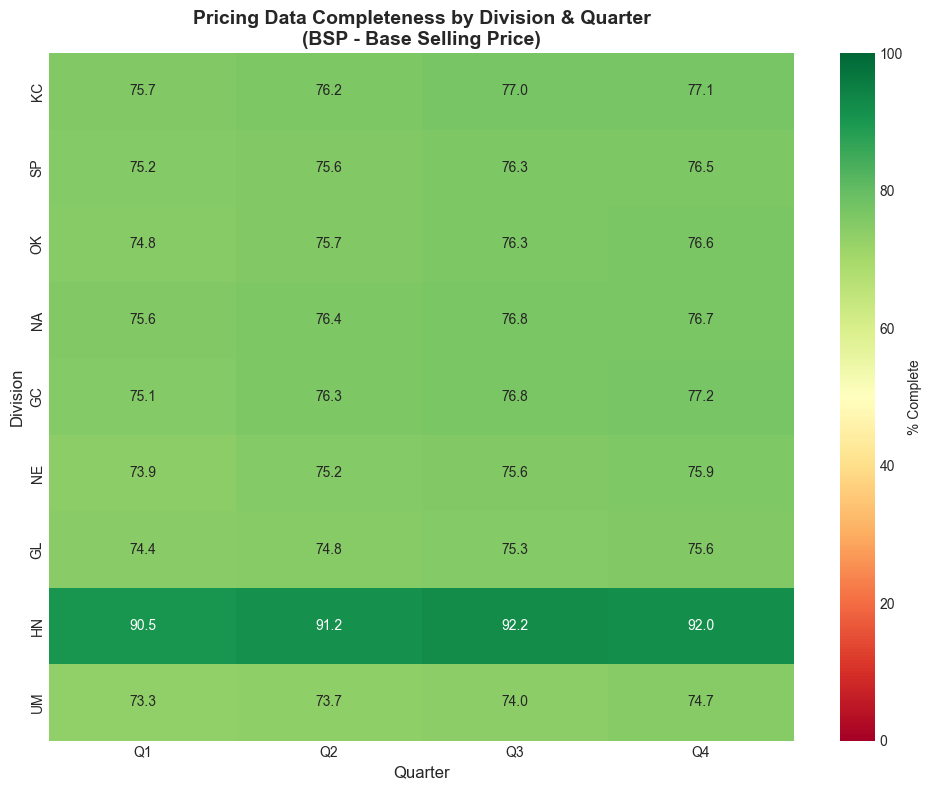


Interpretation:
- Green = High completeness (>80%)
- Yellow = Medium completeness (50-80%)
- Red = Low completeness (<50%)


In [28]:
# =============================================================================
# PRICING COMPLETENESS HEATMAP
# =============================================================================

if df_pricing is not None:
    # Prepare data for heatmap
    heatmap_data = df_div_complete.set_index('Division')[['Q1', 'Q2', 'Q3', 'Q4']]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(heatmap_data, 
                annot=True, 
                fmt='.1f',
                cmap='RdYlGn',
                vmin=0, 
                vmax=100,
                cbar_kws={'label': '% Complete'},
                ax=ax)
    
    ax.set_title('Pricing Data Completeness by Division & Quarter\n(BSP - Base Selling Price)', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Quarter', fontsize=12)
    ax.set_ylabel('Division', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\nInterpretation:")
    print("- Green = High completeness (>80%)")
    print("- Yellow = Medium completeness (50-80%)")
    print("- Red = Low completeness (<50%)")

In [29]:
# =============================================================================
# PRICING COMPLETENESS BY BRAND
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRICING DATA COMPLETENESS BY BRAND")
    print("=" * 60)
    
    # Use KC division as sample (or first available division with data)
    sample_division = 'KC'
    
    brand_completeness = []
    
    for brand in df_pricing['Brand Label Name'].unique():
        if pd.isna(brand):
            continue
            
        brand_df = df_pricing[df_pricing['Brand Label Name'] == brand]
        brand_data = {'Brand': brand, 'Item Count': len(brand_df)}
        
        for suffix, quarter in QUARTER_SUFFIXES.items():
            col_name = get_division_quarter_columns(df_pricing, sample_division, suffix, 'BSP')
            
            if col_name and col_name in brand_df.columns:
                pct_populated = (brand_df[col_name].notna().sum() / len(brand_df)) * 100
                brand_data[quarter] = pct_populated
            else:
                brand_data[quarter] = 0.0
        
        brand_completeness.append(brand_data)
    
    # Create DataFrame
    df_brand_complete = pd.DataFrame(brand_completeness)
    
    print(f"\nPricing completeness by brand ({sample_division} Division):")
    display(df_brand_complete.round(1))

PRICING DATA COMPLETENESS BY BRAND

Pricing completeness by brand (KC Division):


,Brand,Item Count,Q1,Q2,Q3,Q4
0,Always Save,470,88.30,88.90,89.80,89.80
1,Best Choice,2782,74.10,74.70,75.60,75.80
2,National Brand,1067,74.30,74.60,75.20,74.80


In [30]:
# =============================================================================
# PRICING COMPLETENESS BY CATEGORY (TOP 20)
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRICING DATA COMPLETENESS BY CATEGORY (TOP 20)")
    print("=" * 60)
    
    # Get top 20 categories by item count
    top_categories = df_pricing['Category'].value_counts().head(20).index.tolist()
    
    category_completeness = []
    sample_division = 'KC'
    
    for category in top_categories:
        cat_df = df_pricing[df_pricing['Category'] == category]
        cat_data = {'Category': category, 'Item Count': len(cat_df)}
        
        # Check all quarters for this category
        quarter_cols = []
        for suffix, quarter in QUARTER_SUFFIXES.items():
            col_name = get_division_quarter_columns(df_pricing, sample_division, suffix, 'BSP')
            if col_name:
                quarter_cols.append(col_name)
        
        if quarter_cols:
            # % with complete data (all quarters)
            all_complete = cat_df[quarter_cols].notna().all(axis=1).mean() * 100
            cat_data['% Complete'] = all_complete
        else:
            cat_data['% Complete'] = 0.0
        
        category_completeness.append(cat_data)
    
    # Create DataFrame and sort
    df_cat_complete = pd.DataFrame(category_completeness)
    df_cat_complete = df_cat_complete.sort_values('% Complete', ascending=False)
    
    display(df_cat_complete.round(1))

PRICING DATA COMPLETENESS BY CATEGORY (TOP 20)


,Category,Item Count,% Complete
2,CONDIMENTS & SAUCES,158,97.50
18,DESSERTS,79,97.50
8,CEREALS & OTHER BREAKFAST FOODS,123,96.70
3,PREPARED FOODS,147,95.90
10,"CHEESE, NATURAL",117,95.70
12,SOUP,93,95.70
9,"SALT, SEASONINGS, SPICES",123,95.10
7,"FRUIT, CANNED, GLASS & PLASTIC",124,94.40
14,"PICKLES, OLIVES, RELISHES",91,92.30
1,"VEGETABLES, SHELF STABLE",223,91.50


## 4.3 Sales Data Completeness

Similar analysis for sales data across all division sheets.

In [31]:
# =============================================================================
# SALES DATA COMPLETENESS BY DIVISION
# =============================================================================

if sales_data is not None:
    print("=" * 60)
    print("SALES DATA COMPLETENESS BY DIVISION")
    print("=" * 60)
    
    sales_completeness = []
    
    for div_code, df in sales_by_division.items():
        div_data = {
            'Division': div_code,
            'Division Name': DIVISIONS.get(div_code, 'Unknown'),
            'Total Items': len(df)
        }
        
        # Look for sales columns ($ SALES)
        sales_cols = [c for c in df.columns if '$ SALES' in c.upper() or 'SALES' in c.upper()]
        
        if sales_cols:
            # Calculate items with any sales data
            has_any_sales = df[sales_cols].notna().any(axis=1).mean() * 100
            div_data['% With Sales Data'] = has_any_sales
        else:
            div_data['% With Sales Data'] = 0.0
        
        sales_completeness.append(div_data)
    
    df_sales_complete = pd.DataFrame(sales_completeness)
    display(df_sales_complete.round(1))

SALES DATA COMPLETENESS BY DIVISION


,Division,Division Name,Total Items,% With Sales Data
0,KC,Kansas City,4353,92.90
1,SP,Springfield,4353,82.00
2,OK,Oklahoma,4353,80.20
3,NA,Nashville,4353,81.60
4,GC,Gulf Coast,4353,81.30
5,NE,Nebraska,4353,81.40
6,GL,Great Lakes,4353,79.00
7,HN,Hernando,4353,86.30
8,UM,Upper Midwest,4353,82.20


## 4.4 Cross-File Alignment

This section checks how well the pricing and sales files align on Item Codes.

In [32]:
# =============================================================================
# CROSS-FILE ALIGNMENT CHECK
# =============================================================================

if df_pricing is not None and sales_data is not None:
    print("=" * 60)
    print("CROSS-FILE ALIGNMENT ANALYSIS")
    print("=" * 60)
    
    # Get item codes from pricing file
    pricing_items = set(df_pricing['Item Code'].dropna().unique())
    
    # Get item codes from all sales sheets
    sales_items = set()
    for div_code, df in sales_by_division.items():
        if 'Item Code' in df.columns:
            sales_items.update(df['Item Code'].dropna().unique())
    
    # Calculate overlap
    in_both = pricing_items.intersection(sales_items)
    in_pricing_only = pricing_items - sales_items
    in_sales_only = sales_items - pricing_items
    
    print(f"\nItem Code Alignment Summary:")
    print(f"-" * 40)
    print(f"Items in Pricing file:      {len(pricing_items):,}")
    print(f"Items in Sales file(s):     {len(sales_items):,}")
    print(f"Items in BOTH files:        {len(in_both):,} ({len(in_both)/len(pricing_items)*100:.1f}%)")
    print(f"In Pricing ONLY:            {len(in_pricing_only):,}")
    print(f"In Sales ONLY:              {len(in_sales_only):,}")
    
    # Sample items in pricing only
    if len(in_pricing_only) > 0:
        print(f"\n" + "-" * 40)
        print("Sample items in PRICING but not in SALES:")
        sample_pricing_only = list(in_pricing_only)[:5]
        sample_df = df_pricing[df_pricing['Item Code'].isin(sample_pricing_only)][['Item Code', 'Item Name', 'Brand Label Name']]
        display(sample_df)
    
    # Sample items in sales only
    if len(in_sales_only) > 0:
        print(f"\n" + "-" * 40)
        print("Sample items in SALES but not in PRICING:")
        print(list(in_sales_only)[:10])

CROSS-FILE ALIGNMENT ANALYSIS

Item Code Alignment Summary:
----------------------------------------
Items in Pricing file:      4,319
Items in Sales file(s):     4,320
Items in BOTH files:        4,319 (100.0%)
In Pricing ONLY:            0
In Sales ONLY:              1

----------------------------------------
Sample items in SALES but not in PRICING:
[np.int64(201037)]


---

# 5. Brand & Linkage Analysis

---

This section analyzes the brand distribution and validates the linkage between Best Choice and National Brand items.

## 5.1 Brand Distribution

BRAND DISTRIBUTION


,Brand,Count,% of Total
0,Best Choice,2782,64.40
1,National Brand,1067,24.70
2,Always Save,470,10.90


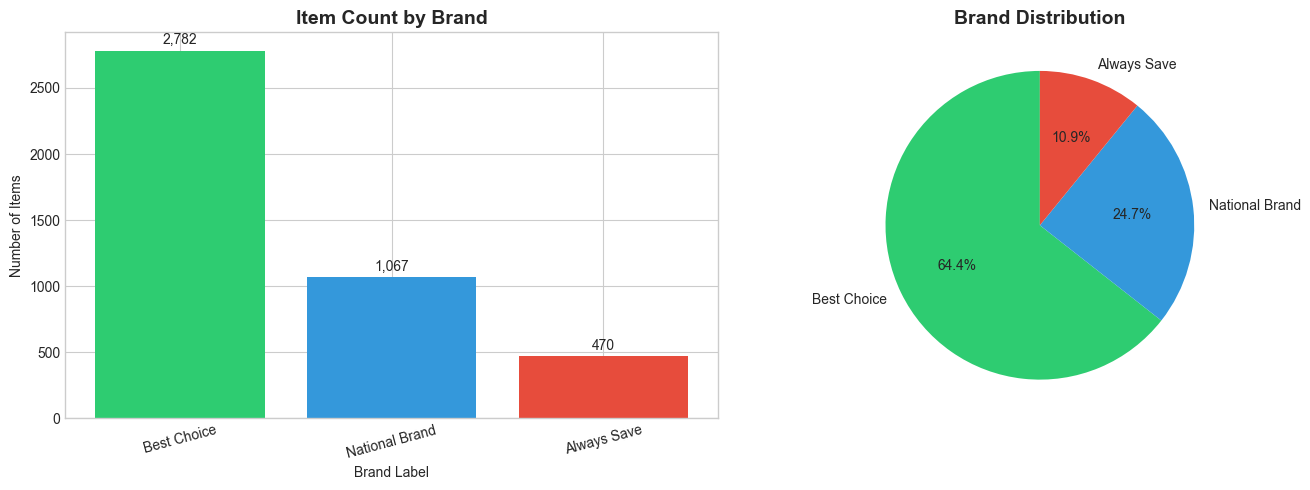

In [33]:
# =============================================================================
# BRAND DISTRIBUTION ANALYSIS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("BRAND DISTRIBUTION")
    print("=" * 60)
    
    # Count by brand
    brand_counts = df_pricing['Brand Label Name'].value_counts()
    
    # Create summary table
    brand_summary = pd.DataFrame({
        'Brand': brand_counts.index,
        'Count': brand_counts.values,
        '% of Total': (brand_counts.values / len(df_pricing) * 100).round(1)
    })
    
    display(brand_summary)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    axes[0].bar(brand_counts.index, brand_counts.values, color=colors)
    axes[0].set_title('Item Count by Brand', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Brand Label')
    axes[0].set_ylabel('Number of Items')
    axes[0].tick_params(axis='x', rotation=15)
    
    # Add count labels on bars
    for i, (brand, count) in enumerate(zip(brand_counts.index, brand_counts.values)):
        axes[0].text(i, count + 50, f'{count:,}', ha='center', fontsize=10)
    
    # Pie chart
    axes[1].pie(brand_counts.values, labels=brand_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[1].set_title('Brand Distribution', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 5.2 National Brand Linkage Validation

Best Choice items should be linked to their National Brand equivalents via the "National Comparison Item Code" field.

In [34]:
# =============================================================================
# NATIONAL BRAND LINKAGE VALIDATION
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("NATIONAL BRAND LINKAGE VALIDATION")
    print("=" * 60)
    
    # Filter Best Choice items
    bc_items = df_pricing[df_pricing['Brand Label Name'] == 'Best Choice'].copy()
    
    print(f"\nTotal Best Choice items: {len(bc_items):,}")
    
    # Check how many have a National Comparison Item Code
    has_linkage = bc_items['National Comparison Item Code'].notna()
    
    print(f"BC items WITH National Comparison Code: {has_linkage.sum():,} ({has_linkage.mean()*100:.1f}%)")
    print(f"BC items WITHOUT National Comparison Code: {(~has_linkage).sum():,} ({(~has_linkage).mean()*100:.1f}%)")
    
    # Check if linked codes actually exist in the data
    linked_codes = bc_items.loc[has_linkage, 'National Comparison Item Code'].unique()
    all_item_codes = set(df_pricing['Item Code'].unique())
    
    valid_links = [code for code in linked_codes if code in all_item_codes]
    invalid_links = [code for code in linked_codes if code not in all_item_codes]
    
    print(f"\nLinked codes that EXIST in data: {len(valid_links):,}")
    print(f"Linked codes that DON'T EXIST: {len(invalid_links):,}")
    
    if invalid_links:
        print(f"\nSample invalid link codes: {invalid_links[:5]}")

NATIONAL BRAND LINKAGE VALIDATION

Total Best Choice items: 2,782
BC items WITH National Comparison Code: 1,093 (39.3%)
BC items WITHOUT National Comparison Code: 1,689 (60.7%)

Linked codes that EXIST in data: 1,062
Linked codes that DON'T EXIST: 1

Sample invalid link codes: [np.float64(201037.0)]


In [35]:
# =============================================================================
# SAMPLE LINKED PAIRS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("SAMPLE LINKED PAIRS (Best Choice vs National Brand)")
    print("=" * 60)
    
    # Get BC items with valid linkages
    bc_with_links = df_pricing[
        (df_pricing['Brand Label Name'] == 'Best Choice') & 
        (df_pricing['National Comparison Item Code'].notna())
    ].copy()
    
    # Sample 10 pairs
    sample_pairs = []
    
    for _, bc_row in bc_with_links.head(10).iterrows():
        national_code = bc_row['National Comparison Item Code']
        
        # Find the national brand item
        national_row = df_pricing[df_pricing['Item Code'] == national_code]
        
        if len(national_row) > 0:
            national_row = national_row.iloc[0]
            
            sample_pairs.append({
                'BC Item Code': bc_row['Item Code'],
                'BC Item Name': bc_row['Item Name'][:30] if pd.notna(bc_row['Item Name']) else '',
                'Category': bc_row['Category'],
                'National Item Code': national_code,
                'National Item Name': national_row['Item Name'][:30] if pd.notna(national_row['Item Name']) else ''
            })
    
    if sample_pairs:
        df_sample_pairs = pd.DataFrame(sample_pairs)
        display(df_sample_pairs)
    else:
        print("No valid linked pairs found.")

SAMPLE LINKED PAIRS (Best Choice vs National Brand)


,BC Item Code,BC Item Name,Category,National Item Code,National Item Name
0,26989,BST CH HND SNTZR ALO,PERSONAL CLEANSING,"111,218.00",PURELL ALOE HND SNTR
1,27351,BST CH ALRGY EYE REF,EYE & EAR CARE,"788,596.00",PATADAY ONCE A DAY
2,30980,BST CH PT PREM 12 RL,PAPER/PLASTIC PRODUCTS,"125,625.00",BNTY 12DPR SAS WHT
3,30981,BST CH PT ULTRA 6 RL,PAPER/PLASTIC PRODUCTS,"205,825.00",BNTY 6DR SAS WHT
4,30982,BST CH PT ULTRA 12RL,PAPER/PLASTIC PRODUCTS,"125,625.00",BNTY 12DPR SAS WHT
5,32996,BST CH LHS MRN BRZ,PERSONAL CLEANSING,"680,540.00",SFTSP LHS FRSH BRZ
6,43419,BST CH MEL/CH/LV GMY,VITAMINS,"741,883.00",V PR Z GMMIES 48CT
7,92239,BST CH ANTINAUS CHRY,DIGESTIVE HEALTH,"703,710.00",EMETROL CHERRY ADULT
8,104547,BST CH INST LIT CHAR,CHARCOAL & LIGHTER FLUIDS,"232,090.00",MATCH LIGHT BRIQ ORG
9,166796,BST CH COMP BLD PELT,CHARCOAL & LIGHTER FLUIDS,"192,644.00",TRAEGER PELLET SIG


## 5.3 Categories with Multiple Brands

Identifying categories that have multiple brand types is critical for cross-brand analysis.

In [36]:
# =============================================================================
# CATEGORIES WITH MULTIPLE BRANDS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("CATEGORIES WITH MULTIPLE BRANDS")
    print("=" * 60)
    
    # Group by category and get unique brands
    category_brands = df_pricing.groupby('Category')['Brand Label Name'].apply(
        lambda x: set(x.dropna())
    ).reset_index()
    category_brands.columns = ['Category', 'Brands']
    
    # Add brand count
    category_brands['Brand Count'] = category_brands['Brands'].apply(len)
    
    # Categories with all three brands
    all_three = category_brands[category_brands['Brand Count'] == 3]
    print(f"\nCategories with ALL THREE brands (BC, AS, National): {len(all_three)}")
    
    if len(all_three) > 0:
        print("\nTop 20 categories with all three brands:")
        # Add item counts
        cat_counts = df_pricing['Category'].value_counts()
        all_three_display = all_three.copy()
        all_three_display['Item Count'] = all_three_display['Category'].map(cat_counts)
        all_three_display = all_three_display.sort_values('Item Count', ascending=False)
        display(all_three_display[['Category', 'Item Count']].head(20))
    
    # Categories with BC and AS
    bc_and_as = category_brands[category_brands['Brands'].apply(
        lambda x: 'Best Choice' in x and 'Always Save' in x
    )]
    print(f"\nCategories with BOTH Best Choice AND Always Save: {len(bc_and_as)}")

CATEGORIES WITH MULTIPLE BRANDS

Categories with ALL THREE brands (BC, AS, National): 56

Top 20 categories with all three brands:


,Category,Item Count
64,PAPER/PLASTIC PRODUCTS,265
99,"VEGETABLES, SHELF STABLE",223
21,CONDIMENTS & SAUCES,158
74,PREPARED FOODS,147
101,"WATER, SOFT DRINKS, MIXES",146
85,SNACKS,140
22,COOKIES - CRACKERS - MISCELLANEOUS BREAD PROD,129
47,"FRUIT, CANNED, GLASS & PLASTIC",124
12,CEREALS & OTHER BREAKFAST FOODS,123
79,"SALT, SEASONINGS, SPICES",123



Categories with BOTH Best Choice AND Always Save: 65


---

# 6. Pricing Data Quality

---

This section performs quality checks on the pricing data.

## 6.1 Price Reasonableness Checks

In [37]:
# =============================================================================
# PRICE REASONABLENESS CHECKS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRICE REASONABLENESS CHECKS")
    print("=" * 60)
    
    # Get all pricing columns
    pricing_cols = df_pricing.columns[13:].tolist()
    
    # Check for negative prices
    negative_prices = 0
    zero_prices = 0
    
    for col in pricing_cols:
        if df_pricing[col].dtype in ['float64', 'int64']:
            negative_prices += (df_pricing[col] < 0).sum()
            zero_prices += (df_pricing[col] == 0).sum()
    
    print(f"\n1. Negative Prices: {negative_prices:,}")
    print(f"2. Zero Prices: {zero_prices:,}")
    
    # Outlier detection for BSP columns
    print("\n3. BSP Price Distribution (KC Division, Q1):")
    
    sample_bsp_col = get_division_quarter_columns(df_pricing, 'KC', '', 'BSP')
    
    if sample_bsp_col and sample_bsp_col in df_pricing.columns:
        bsp_data = df_pricing[sample_bsp_col].dropna()
        
        print(f"   Min: ${bsp_data.min():.2f}")
        print(f"   Max: ${bsp_data.max():.2f}")
        print(f"   Mean: ${bsp_data.mean():.2f}")
        print(f"   Median: ${bsp_data.median():.2f}")
        print(f"   Std Dev: ${bsp_data.std():.2f}")
        
        # Identify outliers (> 3 std dev)
        mean_val = bsp_data.mean()
        std_val = bsp_data.std()
        outliers = bsp_data[bsp_data > mean_val + 3 * std_val]
        
        print(f"\n   Outliers (> 3 std dev): {len(outliers):,} items")
        
        if len(outliers) > 0:
            print(f"   Outlier price range: ${outliers.min():.2f} - ${outliers.max():.2f}")

PRICE REASONABLENESS CHECKS

1. Negative Prices: 0
2. Zero Prices: 1,802

3. BSP Price Distribution (KC Division, Q1):
   Min: $0.00
   Max: $2828.25
   Mean: $56.24
   Median: $24.40
   Std Dev: $199.75

   Outliers (> 3 std dev): 51 items
   Outlier price range: $673.92 - $2828.25


In [38]:
# =============================================================================
# PRICE RELATIONSHIP CHECKS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("PRICE RELATIONSHIP VALIDATION")
    print("=" * 60)
    
    # Get sample columns for KC Q1
    list_cost_col = get_division_quarter_columns(df_pricing, 'KC', '', 'LIST COST')
    bsp_col = get_division_quarter_columns(df_pricing, 'KC', '', 'BSP')
    city_srp_col = get_division_quarter_columns(df_pricing, 'KC', '', 'CITY SRP')
    
    print("\nChecking price relationships for KC Division, Q1:")
    print("-" * 50)
    
    if list_cost_col and bsp_col:
        # Filter rows with both values
        valid_rows = df_pricing[[list_cost_col, bsp_col]].dropna()
        
        # Check: List Cost <= BSP
        cost_gt_bsp = (valid_rows[list_cost_col] > valid_rows[bsp_col]).sum()
        print(f"\n1. List Cost > BSP (unexpected): {cost_gt_bsp:,} items")
        
        if cost_gt_bsp > 0:
            print("   ⚠ Some items have List Cost higher than BSP - needs review")
    
    if bsp_col and city_srp_col:
        # Filter rows with both values
        valid_rows = df_pricing[[bsp_col, city_srp_col]].dropna()
        
        # Check: BSP <= SRP
        bsp_gt_srp = (valid_rows[bsp_col] > valid_rows[city_srp_col]).sum()
        print(f"\n2. BSP > City SRP (unexpected): {bsp_gt_srp:,} items")
        
        if bsp_gt_srp > 0:
            print("   ⚠ Some items have BSP higher than SRP - needs review")

PRICE RELATIONSHIP VALIDATION

Checking price relationships for KC Division, Q1:
--------------------------------------------------

1. List Cost > BSP (unexpected): 322 items
   ⚠ Some items have List Cost higher than BSP - needs review

2. BSP > City SRP (unexpected): 3,218 items
   ⚠ Some items have BSP higher than SRP - needs review


## 6.2 Price Consistency Across Divisions

According to the project requirements, **List Cost should be the same across all divisions**, while SRP may vary.

In [39]:
# =============================================================================
# PRICE CONSISTENCY ACROSS DIVISIONS
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("LIST COST CONSISTENCY ACROSS DIVISIONS")
    print("=" * 60)
    
    # Get List Cost columns for all divisions (Q1)
    list_cost_cols = []
    for div in DIVISIONS.keys():
        col = get_division_quarter_columns(df_pricing, div, '', 'LIST COST')
        if col and col in df_pricing.columns:
            list_cost_cols.append((div, col))
    
    if len(list_cost_cols) >= 2:
        # Check how many items have different List Costs across divisions
        col_names = [c[1] for c in list_cost_cols]
        
        # Get rows with data in all columns
        valid_data = df_pricing[['Item Code'] + col_names].dropna()
        
        # Check for variation
        price_cols_only = valid_data[col_names]
        variation = price_cols_only.std(axis=1)
        has_variation = (variation > 0.01).sum()  # Allow small rounding differences
        
        print(f"\nItems with List Cost data in all divisions: {len(valid_data):,}")
        print(f"Items with SAME List Cost across divisions: {len(valid_data) - has_variation:,}")
        print(f"Items with DIFFERENT List Cost: {has_variation:,}")
        
        if has_variation > 0:
            print("\n⚠ Expected: List Cost should be SAME across divisions")
            print("\nSample items with varying List Cost:")
            varying_items = valid_data[variation > 0.01].head(5)
            display(varying_items)

LIST COST CONSISTENCY ACROSS DIVISIONS

Items with List Cost data in all divisions: 2,848
Items with SAME List Cost across divisions: 1,611
Items with DIFFERENT List Cost: 1,237

⚠ Expected: List Cost should be SAME across divisions

Sample items with varying List Cost:


,Item Code,KC LIST COST,SP LIST COST,OK LIST COST,NA LIST COST,GC LIST COST,NE LIST COST,GL LIST COST,HN LIST COST,UM LIST COST
4,45491,9.98,10.16,10.37,10.34,10.83,9.75,9.91,10.38,9.54
6,166614,11.93,12.70,12.11,11.54,11.96,13.28,12.48,11.63,14.39
7,351452,6.37,6.33,5.99,7.34,7.90,6.41,6.66,6.18,6.02
8,370569,5.45,6.19,5.93,6.93,6.93,6.43,4.96,7.30,6.37
14,26345,13.54,13.67,13.92,13.64,13.89,13.57,13.30,13.69,13.46


## 6.3 Quarter-over-Quarter Price Changes

Analyzing how prices changed throughout the year.

In [40]:
# =============================================================================
# QUARTER-OVER-QUARTER PRICE CHANGES
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("QUARTER-OVER-QUARTER PRICE CHANGES (KC Division)")
    print("=" * 60)
    
    # Get BSP columns for all quarters in KC
    quarter_cols = {}
    for suffix, quarter in QUARTER_SUFFIXES.items():
        col = get_division_quarter_columns(df_pricing, 'KC', suffix, 'BSP')
        if col and col in df_pricing.columns:
            quarter_cols[quarter] = col
    
    if len(quarter_cols) == 4:
        print("\nPrice Change Analysis (BSP):")
        print("-" * 50)
        
        changes = []
        quarter_list = ['Q1', 'Q2', 'Q3', 'Q4']
        
        for i in range(len(quarter_list) - 1):
            q_from = quarter_list[i]
            q_to = quarter_list[i + 1]
            
            col_from = quarter_cols[q_from]
            col_to = quarter_cols[q_to]
            
            # Get rows with both values
            valid = df_pricing[[col_from, col_to]].dropna()
            
            # Calculate changes
            price_changed = (valid[col_from] != valid[col_to]).sum()
            pct_changed = (price_changed / len(valid)) * 100 if len(valid) > 0 else 0
            
            changes.append({
                'Period': f'{q_from} → {q_to}',
                'Items with Data': len(valid),
                'Items with Price Change': price_changed,
                '% Changed': f'{pct_changed:.1f}%'
            })
        
        # Items with ANY change during year
        all_qtrs = df_pricing[list(quarter_cols.values())].dropna()
        any_change = (all_qtrs.nunique(axis=1) > 1).sum()
        pct_any_change = (any_change / len(all_qtrs)) * 100 if len(all_qtrs) > 0 else 0
        
        changes.append({
            'Period': 'Any Change (Q1-Q4)',
            'Items with Data': len(all_qtrs),
            'Items with Price Change': any_change,
            '% Changed': f'{pct_any_change:.1f}%'
        })
        
        display(pd.DataFrame(changes))

QUARTER-OVER-QUARTER PRICE CHANGES (KC Division)

Price Change Analysis (BSP):
--------------------------------------------------


,Period,Items with Data,Items with Price Change,% Changed
0,Q1 → Q2,3240,238,7.3%
1,Q2 → Q3,3282,383,11.7%
2,Q3 → Q4,3299,487,14.8%
3,Any Change (Q1-Q4),3212,858,26.7%


PRICE CHANGE MAGNITUDE DISTRIBUTION


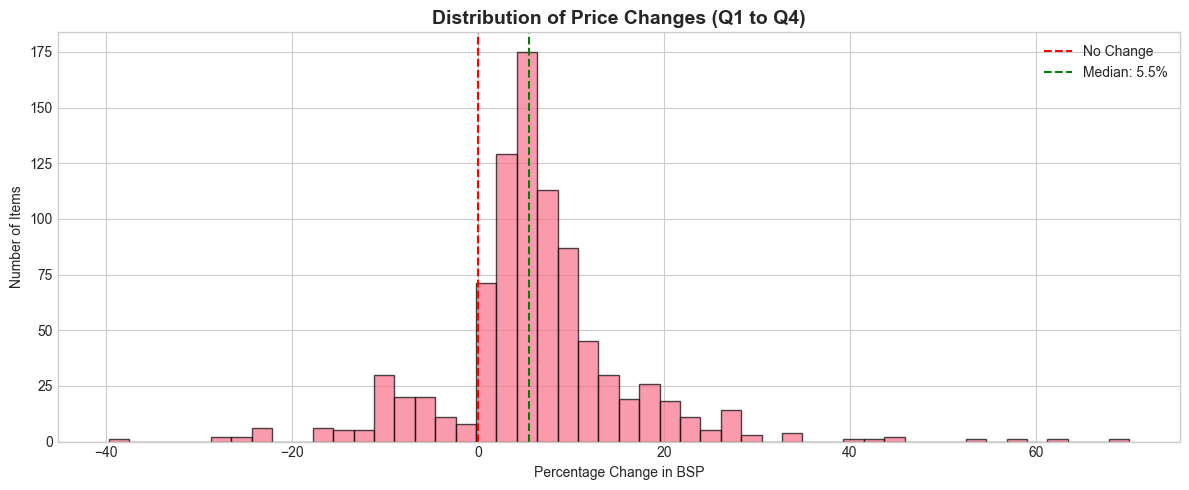


Change Statistics:
  Items with price increases: 758
  Items with price decreases: 116
  Average change: 6.22%
  Median change: 5.52%


In [41]:
# =============================================================================
# PRICE CHANGE DISTRIBUTION
# =============================================================================

if df_pricing is not None and len(quarter_cols) >= 2:
    print("=" * 60)
    print("PRICE CHANGE MAGNITUDE DISTRIBUTION")
    print("=" * 60)
    
    # Calculate Q1 to Q4 change
    q1_col = quarter_cols.get('Q1')
    q4_col = quarter_cols.get('Q4')
    
    if q1_col and q4_col:
        valid_data = df_pricing[[q1_col, q4_col]].dropna()
        valid_data = valid_data[valid_data[q1_col] > 0]  # Avoid division by zero
        
        # Calculate percentage change
        valid_data['pct_change'] = ((valid_data[q4_col] - valid_data[q1_col]) / valid_data[q1_col]) * 100
        
        # Filter to items that changed
        changed = valid_data[valid_data['pct_change'] != 0]
        
        if len(changed) > 0:
            fig, ax = plt.subplots(figsize=(12, 5))
            
            ax.hist(changed['pct_change'], bins=50, edgecolor='black', alpha=0.7)
            ax.axvline(x=0, color='red', linestyle='--', label='No Change')
            ax.axvline(x=changed['pct_change'].median(), color='green', linestyle='--', 
                      label=f'Median: {changed["pct_change"].median():.1f}%')
            
            ax.set_title('Distribution of Price Changes (Q1 to Q4)', fontsize=14, fontweight='bold')
            ax.set_xlabel('Percentage Change in BSP')
            ax.set_ylabel('Number of Items')
            ax.legend()
            
            plt.tight_layout()
            plt.show()
            
            print(f"\nChange Statistics:")
            print(f"  Items with price increases: {(changed['pct_change'] > 0).sum():,}")
            print(f"  Items with price decreases: {(changed['pct_change'] < 0).sum():,}")
            print(f"  Average change: {changed['pct_change'].mean():.2f}%")
            print(f"  Median change: {changed['pct_change'].median():.2f}%")

---

# 7. Sales Data Quality

---

## 7.1 Sales Reasonableness Checks

In [42]:
# =============================================================================
# SALES REASONABLENESS CHECKS
# =============================================================================

if sales_data is not None:
    print("=" * 60)
    print("SALES DATA REASONABLENESS CHECKS")
    print("=" * 60)
    
    # Combine all sales data for analysis
    all_sales = []
    
    for div_code, df in sales_by_division.items():
        df_copy = df.copy()
        df_copy['Division'] = div_code
        all_sales.append(df_copy)
    
    combined_sales = pd.concat(all_sales, ignore_index=True)
    
    # Find sales columns
    sales_cols = [c for c in combined_sales.columns if '$ SALES' in c.upper() or 'SALES' in c.upper()]
    qty_cols = [c for c in combined_sales.columns if 'QUANTITY' in c.upper() or 'BILLED' in c.upper()]
    
    print(f"\nSales columns found: {sales_cols[:4]}...")
    print(f"Quantity columns found: {qty_cols[:4]}...")
    
    # Check for negative values
    if sales_cols:
        negative_sales = 0
        zero_sales = 0
        
        for col in sales_cols:
            if combined_sales[col].dtype in ['float64', 'int64']:
                negative_sales += (combined_sales[col] < 0).sum()
                zero_sales += (combined_sales[col] == 0).sum()
        
        print(f"\n1. Negative Sales Values: {negative_sales:,}")
        print(f"2. Zero Sales Values: {zero_sales:,}")
        
        if negative_sales > 0:
            print("   ⚠ Negative sales may indicate returns or corrections")

SALES DATA REASONABLENESS CHECKS

Sales columns found: ['$ SALES', '$ SALES.1', '$ SALES.2', '$ SALES.3']...
Quantity columns found: ['BILLED CASE QUANTITY', 'BILLED CASE QUANTITY.1', 'BILLED CASE QUANTITY.2', 'BILLED CASE QUANTITY.3']...

1. Negative Sales Values: 0
2. Zero Sales Values: 5,947


In [43]:
# =============================================================================
# SALES DISTRIBUTION BY BRAND
# =============================================================================

if sales_data is not None and df_pricing is not None:
    print("=" * 60)
    print("SALES DISTRIBUTION BY BRAND")
    print("=" * 60)
    
    # Get sample sales sheet
    sample_div = list(sales_by_division.keys())[0]
    sample_sales = sales_by_division[sample_div].copy()
    
    # Merge with pricing to get brand info
    if 'Item Code' in sample_sales.columns:
        sample_sales = sample_sales.merge(
            df_pricing[['Item Code', 'Brand Label Name']], 
            on='Item Code', 
            how='left'
        )
        
        # Find first sales column
        sales_col = [c for c in sample_sales.columns if '$ SALES' in c.upper()]
        
        if sales_col and 'Brand Label Name' in sample_sales.columns:
            sales_col = sales_col[0]
            
            # Summarize by brand
            brand_sales = sample_sales.groupby('Brand Label Name')[sales_col].agg(['sum', 'mean', 'count'])
            brand_sales.columns = ['Total Sales ($)', 'Avg Sales ($)', 'Item Count']
            brand_sales = brand_sales.sort_values('Total Sales ($)', ascending=False)
            
            print(f"\nSales Summary by Brand ({sample_div} Division, {sales_col}):")
            display(brand_sales.round(2))

SALES DISTRIBUTION BY BRAND


## 7.2 Sales vs Pricing Alignment

In [44]:
# =============================================================================
# SALES VS PRICING ALIGNMENT
# =============================================================================

if sales_data is not None and df_pricing is not None:
    print("=" * 60)
    print("SALES VS PRICING ALIGNMENT")
    print("=" * 60)
    
    # For each division, check alignment
    alignment_results = []
    
    for div_code, sales_df in sales_by_division.items():
        if 'Item Code' not in sales_df.columns:
            continue
        
        sales_items = set(sales_df['Item Code'].dropna())
        
        # Get pricing column for this division
        bsp_col = get_division_quarter_columns(df_pricing, div_code, '', 'BSP')
        
        if bsp_col:
            # Items with both sales and pricing
            items_with_pricing = set(df_pricing[df_pricing[bsp_col].notna()]['Item Code'])
            items_with_both = sales_items.intersection(items_with_pricing)
            
            alignment_results.append({
                'Division': div_code,
                'Items with Sales': len(sales_items),
                'Items with Both Sales & Pricing': len(items_with_both),
                '% Aligned': f"{len(items_with_both)/len(sales_items)*100:.1f}%" if sales_items else "N/A"
            })
    
    if alignment_results:
        display(pd.DataFrame(alignment_results))

SALES VS PRICING ALIGNMENT


,Division,Items with Sales,Items with Both Sales & Pricing,% Aligned
0,KC,4320,3269,75.7%
1,SP,4320,3249,75.2%
2,OK,4320,3232,74.8%
3,NA,4320,3264,75.6%
4,GC,4320,3243,75.1%
5,NE,4320,3192,73.9%
6,GL,4320,3213,74.4%
7,HN,4320,3910,90.5%
8,UM,4320,3167,73.3%


---

# 8. Key Categories Deep Dive

---

Based on the project meeting, these categories are of particular interest:

| Category | Reason for Interest |
|----------|--------------------|
| Coffee & Creamers | Tariff-sensitive |
| Oils/Shortenings | Significant price movement |
| Chocolate/Baking | Hershey's example discussed |

In [45]:
# =============================================================================
# KEY CATEGORIES DEEP DIVE
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("KEY CATEGORIES DEEP DIVE")
    print("=" * 60)
    
    # Define key categories to search for
    key_category_patterns = {
        'Coffee & Creamers': ['COFFEE', 'CREAMER'],
        'Oils/Shortenings': ['OIL', 'SHORTENING', 'VEGETABLE'],
        'Chocolate/Baking': ['CHOCOLATE', 'BAKING', 'COCOA', 'HERSHEY']
    }
    
    for category_name, patterns in key_category_patterns.items():
        print(f"\n{'='*60}")
        print(f"{category_name.upper()}")
        print(f"{'='*60}")
        
        # Find matching items
        mask = df_pricing['Category'].str.upper().str.contains('|'.join(patterns), na=False)
        category_items = df_pricing[mask]
        
        if len(category_items) == 0:
            # Try Item Name
            mask = df_pricing['Item Name'].str.upper().str.contains('|'.join(patterns), na=False)
            category_items = df_pricing[mask]
        
        print(f"\nTotal items found: {len(category_items):,}")
        
        if len(category_items) > 0:
            # Brand breakdown
            brand_counts = category_items['Brand Label Name'].value_counts()
            print(f"\nBy Brand:")
            for brand, count in brand_counts.items():
                print(f"  {brand}: {count}")
            
            # Pricing completeness
            bsp_col = get_division_quarter_columns(df_pricing, 'KC', '', 'BSP')
            if bsp_col:
                pct_with_pricing = category_items[bsp_col].notna().mean() * 100
                print(f"\nPricing completeness (KC BSP): {pct_with_pricing:.1f}%")
            
            # Sample items
            print(f"\nSample items:")
            display(category_items[['Item Code', 'Item Name', 'Brand Label Name', 'Category']].head(5))

KEY CATEGORIES DEEP DIVE

COFFEE & CREAMERS

Total items found: 91

By Brand:
  Best Choice: 59
  National Brand: 19
  Always Save: 13

Pricing completeness (KC BSP): 82.4%

Sample items:


,Item Code,Item Name,Brand Label Name,Category
214,963959,MEL BSKT FLTR NAT,National Brand,COFFEE FILTERS
217,900803,MEL BSKT FLTR WHT BG,National Brand,COFFEE FILTERS
223,963942,MEL BSKT FLTR WHT,National Brand,COFFEE FILTERS
331,246046,BST CH DONUT SHP COF,Best Choice,COFFEE & NON-DAIRY CREAMERS
332,246666,BST CH COLOMBIAN COF,Best Choice,COFFEE & NON-DAIRY CREAMERS



OILS/SHORTENINGS

Total items found: 411

By Brand:
  Best Choice: 270
  National Brand: 92
  Always Save: 49

Pricing completeness (KC BSP): 90.8%

Sample items:


,Item Code,Item Name,Brand Label Name,Category
6,166614,AL SAVE LONG RICE,Always Save,"VEGETABLES, DRIED"
64,273655,BST CH PEANUT OIL BX,Best Choice,SHORTENINGS - OILS
452,249441,AL SAVE PURE VEG OIL,Always Save,SHORTENINGS - OILS
460,390336,AL SAVE PINTO BEANS,Always Save,"VEGETABLES, DRIED"
502,123232,BST CH COB CORN,Best Choice,FROZEN VEGETABLES



CHOCOLATE/BAKING

Total items found: 185

By Brand:
  Best Choice: 95
  National Brand: 66
  Always Save: 24

Pricing completeness (KC BSP): 90.3%

Sample items:


,Item Code,Item Name,Brand Label Name,Category
291,362841,AL SAVE INST MLK 20Q,Always Save,BAKING NEEDS
628,361158,AL SAVE BAKING SODA,Always Save,BAKING NEEDS
652,19148,BST CH CARAMEL SYRUP,Best Choice,COCOA & MILK MODIFIERS
654,19278,BST CH SF CHOC SYRUP,Best Choice,COCOA & MILK MODIFIERS
848,250538,BST CH INSTANT MILK,Best Choice,BAKING NEEDS


---

# 9. Issues Summary Table

---

This section consolidates all identified data quality issues.

In [46]:
# =============================================================================
# CONSOLIDATED ISSUES TABLE
# =============================================================================

print("=" * 60)
print("CONSOLIDATED ISSUES SUMMARY")
print("=" * 60)

# Define issues (update based on actual findings)
issues = [
    {
        'Issue ID': 1,
        'Issue Description': 'Missing pricing data in multiple divisions',
        'Severity': 'High',
        'Affected Records': 'TBD - Update after analysis',
        'Recommended Action': 'Clarify with AWG which items should have pricing'
    },
    {
        'Issue ID': 2,
        'Issue Description': 'Sales sheet name typos (GO→NA, NO→NE)',
        'Severity': 'Low',
        'Affected Records': '2 sheets',
        'Recommended Action': 'Apply sheet name mapping in code'
    },
    {
        'Issue ID': 3,
        'Issue Description': 'Trailing whitespace in "National Brand" label',
        'Severity': 'Low',
        'Affected Records': 'All National Brand items',
        'Recommended Action': 'Apply .str.strip() to Brand Label Name'
    },
    {
        'Issue ID': 4,
        'Issue Description': 'Duplicate column names (SRP UNIT QUANTITY)',
        'Severity': 'Medium',
        'Affected Records': 'Multiple columns',
        'Recommended Action': 'Rename or select specific columns by position'
    },
    {
        'Issue ID': 5,
        'Issue Description': 'Items in pricing but not in sales (or vice versa)',
        'Severity': 'Medium',
        'Affected Records': 'TBD - Update after analysis',
        'Recommended Action': 'Determine if these are new/discontinued items'
    },
    {
        'Issue ID': 6,
        'Issue Description': 'Missing National Brand linkage for some BC items',
        'Severity': 'Medium',
        'Affected Records': 'TBD - Update after analysis',
        'Recommended Action': 'Identify categories where linkage is critical'
    }
]

df_issues = pd.DataFrame(issues)

# Style the table
def highlight_severity(val):
    if val == 'High':
        return 'background-color: #ffcccc'
    elif val == 'Medium':
        return 'background-color: #ffffcc'
    else:
        return 'background-color: #ccffcc'

styled_issues = df_issues.style.applymap(highlight_severity, subset=['Severity'])
display(styled_issues)

CONSOLIDATED ISSUES SUMMARY


,Issue ID,Issue Description,Severity,Affected Records,Recommended Action
0,1,Missing pricing data in multiple divisions,High,TBD - Update after analysis,Clarify with AWG which items should have pricing
1,2,"Sales sheet name typos (GO→NA, NO→NE)",Low,2 sheets,Apply sheet name mapping in code
2,3,"Trailing whitespace in ""National Brand"" label",Low,All National Brand items,Apply .str.strip() to Brand Label Name
3,4,Duplicate column names (SRP UNIT QUANTITY),Medium,Multiple columns,Rename or select specific columns by position
4,5,Items in pricing but not in sales (or vice versa),Medium,TBD - Update after analysis,Determine if these are new/discontinued items
5,6,Missing National Brand linkage for some BC items,Medium,TBD - Update after analysis,Identify categories where linkage is critical


---

# 10. Recommendations

---

## 10.1 Questions for AWG (Data Clarification Needed)

In [47]:
# =============================================================================
# QUESTIONS FOR AWG
# =============================================================================

print("=" * 60)
print("QUESTIONS FOR AWG")
print("=" * 60)

awg_questions = """
1. **Missing Pricing Data**
   - Why do ~X% of items lack pricing in certain divisions?
   - Are these discontinued items, regional exclusives, or data entry gaps?

2. **National Brand Linkage**
   - For Best Choice items without a National Comparison Item Code, how should we handle pricing comparisons?
   - Are there any planned updates to add missing linkages?

3. **Price Change Notifications**
   - Can you confirm that price changes should not occur more than once per quarter?
   - How should we interpret items with multiple price changes?

4. **Sales Data Timeframe**
   - Do the sales quarters align with the pricing quarters?
   - Are there any known data collection gaps?

5. **Category Classification**
   - Are there specific categories we should prioritize for the tariff analysis?
   - Can you provide a list of tariff-impacted categories?
"""

display(Markdown(awg_questions))

QUESTIONS FOR AWG



1. **Missing Pricing Data**
   - Why do ~X% of items lack pricing in certain divisions?
   - Are these discontinued items, regional exclusives, or data entry gaps?

2. **National Brand Linkage**
   - For Best Choice items without a National Comparison Item Code, how should we handle pricing comparisons?
   - Are there any planned updates to add missing linkages?

3. **Price Change Notifications**
   - Can you confirm that price changes should not occur more than once per quarter?
   - How should we interpret items with multiple price changes?

4. **Sales Data Timeframe**
   - Do the sales quarters align with the pricing quarters?
   - Are there any known data collection gaps?

5. **Category Classification**
   - Are there specific categories we should prioritize for the tariff analysis?
   - Can you provide a list of tariff-impacted categories?


## 10.2 Data Preparation Steps

In [48]:
# =============================================================================
# DATA PREPARATION RECOMMENDATIONS
# =============================================================================

print("=" * 60)
print("DATA PREPARATION RECOMMENDATIONS")
print("=" * 60)

prep_steps = """
### Immediate Cleaning Steps

1. **Brand Label Cleaning**
   ```python
   df['Brand Label Name'] = df['Brand Label Name'].str.strip()
   ```

2. **Sales Sheet Mapping**
   ```python
   SHEET_CORRECTIONS = {'GO Division Sales': 'NA', 'NO Division Sales': 'NE'}
   ```

3. **Handle Duplicate Columns**
   - Rename duplicate "SRP UNIT QUANTITY" columns
   - Or select by position: `df.iloc[:, position]`

### Data Transformation

4. **Reshape Pricing Data**
   - Consider melting wide format to long format for easier analysis
   - Create separate Division, Quarter columns

5. **Calculate Derived Fields**
   - Price Gap = (National BSP - BC BSP) / National BSP
   - QoQ Change = (Q2 BSP - Q1 BSP) / Q1 BSP

### Quality Filters

6. **Create Analysis-Ready Subsets**
   - Items with complete pricing (all 4 quarters)
   - Items with valid National Brand linkage
   - Items with both pricing and sales data
"""

display(Markdown(prep_steps))

DATA PREPARATION RECOMMENDATIONS



### Immediate Cleaning Steps

1. **Brand Label Cleaning**
   ```python
   df['Brand Label Name'] = df['Brand Label Name'].str.strip()
   ```

2. **Sales Sheet Mapping**
   ```python
   SHEET_CORRECTIONS = {'GO Division Sales': 'NA', 'NO Division Sales': 'NE'}
   ```

3. **Handle Duplicate Columns**
   - Rename duplicate "SRP UNIT QUANTITY" columns
   - Or select by position: `df.iloc[:, position]`

### Data Transformation

4. **Reshape Pricing Data**
   - Consider melting wide format to long format for easier analysis
   - Create separate Division, Quarter columns

5. **Calculate Derived Fields**
   - Price Gap = (National BSP - BC BSP) / National BSP
   - QoQ Change = (Q2 BSP - Q1 BSP) / Q1 BSP

### Quality Filters

6. **Create Analysis-Ready Subsets**
   - Items with complete pricing (all 4 quarters)
   - Items with valid National Brand linkage
   - Items with both pricing and sales data


## 10.3 Analysis Feasibility Assessment

In [49]:
# =============================================================================
# ANALYSIS FEASIBILITY
# =============================================================================

print("=" * 60)
print("ANALYSIS FEASIBILITY ASSESSMENT")
print("=" * 60)

feasibility = [
    {
        'Analysis': 'Price Gap Analysis (BC vs National)',
        'Feasibility': 'Feasible',
        'Data Requirement': 'Items with National linkage',
        'Notes': 'Limited to items with valid National Comparison Code'
    },
    {
        'Analysis': 'Cost Pass-Through Analysis',
        'Feasibility': 'Feasible',
        'Data Requirement': 'List Cost and BSP data',
        'Notes': 'Compare List Cost changes to BSP changes'
    },
    {
        'Analysis': 'Price Elasticity Analysis',
        'Feasibility': 'Conditional',
        'Data Requirement': 'Both pricing and sales data',
        'Notes': 'Limited to items with aligned data in both files'
    },
    {
        'Analysis': 'Cross-Brand Effects (BC vs AS)',
        'Feasibility': 'Conditional',
        'Data Requirement': 'Categories with both BC and AS',
        'Notes': 'Only for categories with multiple brands'
    },
    {
        'Analysis': 'Division-Level Price Variation',
        'Feasibility': 'Feasible',
        'Data Requirement': 'SRP data across divisions',
        'Notes': 'Good data availability'
    },
    {
        'Analysis': 'Tariff Impact Detection',
        'Feasibility': 'Feasible',
        'Data Requirement': 'QoQ price changes',
        'Notes': 'Look for unusual changes in Q2-Q4'
    }
]

df_feasibility = pd.DataFrame(feasibility)
display(df_feasibility)

ANALYSIS FEASIBILITY ASSESSMENT


,Analysis,Feasibility,Data Requirement,Notes
0,Price Gap Analysis (BC vs National),Feasible,Items with National linkage,Limited to items with valid National Compariso...
1,Cost Pass-Through Analysis,Feasible,List Cost and BSP data,Compare List Cost changes to BSP changes
2,Price Elasticity Analysis,Conditional,Both pricing and sales data,Limited to items with aligned data in both files
3,Cross-Brand Effects (BC vs AS),Conditional,Categories with both BC and AS,Only for categories with multiple brands
4,Division-Level Price Variation,Feasible,SRP data across divisions,Good data availability
5,Tariff Impact Detection,Feasible,QoQ price changes,Look for unusual changes in Q2-Q4


---

# 11. Appendix

---

## A. Column Reference

In [50]:
# =============================================================================
# APPENDIX A: COLUMN REFERENCE
# =============================================================================

if df_pricing is not None:
    print("=" * 60)
    print("APPENDIX A: FULL COLUMN LIST")
    print("=" * 60)
    
    print("\n--- Product Attribute Columns (1-13) ---")
    for i, col in enumerate(df_pricing.columns[:13], 1):
        print(f"  {i:2}. {col}")
    
    print("\n--- Sample Pricing Columns (14-30) ---")
    for i, col in enumerate(df_pricing.columns[13:30], 14):
        print(f"  {i:2}. {col}")
    
    print(f"\n  ... ({len(df_pricing.columns) - 30} more pricing columns)")

APPENDIX A: FULL COLUMN LIST

--- Product Attribute Columns (1-13) ---
   1. Item Code
   2. Item Unit UPC Code
   3. Case UPC Code
   4. Size
   5. Pack (Units per Case)
   6. Item Name
   7. Inventory Department
   8. Category
   9. Sub Category
  10. Brand Label Name
  11. Brand Name
  12. Item Long Description
  13. National Comparison Item Code

--- Sample Pricing Columns (14-30) ---
  14. KC LIST COST
  15. KC BSP
  16. KC SRP UNIT QUANTITY
  17. KC CITY SRP
  18. KC SRP UNIT QUANTITY.1
  19. KC RURAL  SRP
  20. KC LIST COST.1
  21. KC BSP.1
  22. KC SRP UNIT QUANTITY.2
  23. KC CITY SRP.1
  24. KC SRP UNIT QUANTITY.3
  25. KC RURAL  SRP.1
  26. KC LIST COST.2
  27. KC BSP.2
  28. KC SRP UNIT QUANTITY.4
  29. KC CITY SRP.2
  30. KC SRP UNIT QUANTITY.5

  ... (199 more pricing columns)


## B. Division Mapping

In [51]:
# =============================================================================
# APPENDIX B: DIVISION MAPPING
# =============================================================================

print("=" * 60)
print("APPENDIX B: DIVISION MAPPING")
print("=" * 60)

division_info = [
    {'Code': code, 'Full Name': name}
    for code, name in DIVISIONS.items()
]

display(pd.DataFrame(division_info))

print("\n--- Sales Sheet Name Corrections ---")
for wrong, right in SHEET_NAME_CORRECTIONS.items():
    print(f"  '{wrong}' → {right} ({DIVISIONS.get(right, 'Unknown')})")

APPENDIX B: DIVISION MAPPING


,Code,Full Name
0,KC,Kansas City
1,SP,Springfield
2,OK,Oklahoma
3,NA,Nashville
4,GC,Gulf Coast
5,NE,Nebraska
6,GL,Great Lakes
7,HN,Hernando
8,UM,Upper Midwest



--- Sales Sheet Name Corrections ---
  'GO Division Sales' → NA (Nashville)
  'NO Division Sales' → NE (Nebraska)


## C. Sample Data Preview

In [52]:
# =============================================================================
# APPENDIX C: SAMPLE DATA PREVIEW
# =============================================================================

print("=" * 60)
print("APPENDIX C: SAMPLE DATA PREVIEW")
print("=" * 60)

if df_pricing is not None:
    print("\n--- Pricing Data (First 5 Rows, Key Columns) ---")
    display(df_pricing[PRODUCT_COLUMNS[:8]].head())

if sales_data is not None:
    first_sheet = list(sales_data.keys())[0]
    print(f"\n--- Sales Data: {first_sheet} (First 5 Rows) ---")
    display(sales_data[first_sheet].head())

APPENDIX C: SAMPLE DATA PREVIEW

--- Pricing Data (First 5 Rows, Key Columns) ---


,Item Code,Item Unit UPC Code,Case UPC Code,Size,Pack (Units per Case),Item Name,Inventory Department,Category
0,31120,7003866694,7003866694,50 CT,1,AL SAVE CHST&NASL PE,Health Beauty Care,COUGH & COLD REMEDIES
1,31139,7003866837,7003866837,500 CT,1,AL SAVE PN RLF CAPS,Health Beauty Care,PAIN REMEDIES
2,37447,7003866701,7003866701,1 OZ,1,AL SAVE BACITRCN OIT,Health Beauty Care,FIRST AID
3,37573,7003866699,7003866699,1 OZ,1,AL SAVE 1% HYDO CRM,Health Beauty Care,FIRST AID
4,45491,7003867293,7003867293,15 LB,1,AL SAVE CHUNK DOG FD,Grocery - Dry,PET CARE



--- Sales Data: KC Division Sales (First 5 Rows) ---


,Item Code,Item Unit UPC Code,Case UPC Code,Size,Item Name,Brand Label Name,Brand Name,Item Long Description,National Comparison Item Code,Size.1,Item Name.1,$ SALES,BILLED CASE QUANTITY,$ SALES.1,BILLED CASE QUANTITY.1,$ SALES.2,BILLED CASE QUANTITY.2,$ SALES.3,BILLED CASE QUANTITY.3
0,719757,"7,003,858,560.00","7,003,858,560.00",1 GAL,BST CH ANTIFRZ BEST,Best Choice,BEST CHOICE,ANTI-FREEZE AND SUMMER COOLANT,"995,233.00",1 GAL,PRSTN ANTFRZ,"3,667.20",64.00,"2,007.47",35.00,"2,133.64",37.00,"1,849.24",32.00
1,704684,"7,003,858,475.00","7,003,858,475.00",CT,BST CH 10W-40 OIL,Best Choice,BEST CHOICE,SAE 10W-40 MOTOR OIL,"992,958.00",CT,PEN 10W 40,"1,947.60",47.00,"1,913.83",46.00,"2,543.46",61.00,"1,668.50",40.00
2,704676,"7,003,858,474.00","7,003,858,474.00",CT,BST CH 10W-30 OIL,Best Choice,BEST CHOICE,SAE 10 W 30 MOTOR OIL,"992,941.00",CT,PEN 10W 30,"2,878.08",69.00,"2,004.88",48.00,"2,915.45",70.00,"2,468.27",59.00
3,565566,"7,003,863,390.00","7,003,863,390.00",1 QT,BST CH SAE 30 OIL,Best Choice,BEST CHOICE,SAE 30 MOTOR OIL,"992,933.00",CT,PEN 30W,"1,170.72",28.00,"1,163.74",28.00,"1,344.91",32.00,897.73,21.00
4,714295,"7,003,858,960.00","7,003,858,960.00",CT,BST CH 5W-30 OIL,Best Choice,BEST CHOICE,5W - 30 MOTOR OIL,"992,917.00",CT,PEN 5W30,"6,897.12",166.00,"6,197.97",149.00,"7,386.54",178.00,"6,045.00",145.00


---

# End of Report

---

**Report Generated:** January 2026  
**Next Steps:** 
1. Review findings with project team
2. Send clarification questions to AWG
3. Proceed with data cleaning based on recommendations
4. Begin analysis phase

---

*This report was prepared for the U of I Spring 2026 AWG Brands Pricing Analysis Project.*